In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# styling for plots
import scienceplots
plt.style.use(["science", "grid"])
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
})

In [31]:
# reading data
df_na = pd.read_csv("data/national accounts.csv")
df_cap = pd.read_csv("data/capital accounts.csv")

# filtering masks
mask_na = (
    df_na["geo_code"].isin(["PL", "BE"])
    & (df_na["nace_r2_name"] == "Total - all NACE activities")
)
mask_cap = (
    df_cap["geo_code"].isin(["PL", "BE"])
    & (df_cap["nace_r2_name"] == "Total - all NACE activities")
)

# selecting variables and applying masks
df_na_plbe = df_na.loc[
    mask_na, ["geo_code", "year", "COMP", "VA_CP", "VA_Q"]
].copy()

df_cap_plbe = df_cap.loc[
    mask_cap, ["geo_code", "year", "Kq_GFCF"]
].copy()

# mergin on country code and year
df = df_na_plbe.merge(
    df_cap_plbe,
    on=["geo_code", "year"],
    how="inner",
    validate="one_to_one",
)

# encoding numerical vars
cols = ["COMP", "VA_CP", "VA_Q", "Kq_GFCF"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

# calculating shares
df["labour_share"] = df["COMP"] / df["VA_CP"]
df["capital_output"] = df["Kq_GFCF"] / df["VA_Q"]

# Align countries on years with observations for both
labour_income_shares = (
    df.pivot(index="year", columns="geo_code", values="labour_share")
    .sort_index()
    .dropna()
    .rename(columns={"BE": "Belgium", "PL": "Poland"})
)

capital_output = (
    df.pivot(index="year", columns="geo_code", values="capital_output")
    .sort_index()
    .dropna()
    .rename(columns={"BE": "Belgium", "PL": "Poland"})
)

display(labour_income_shares.head(), capital_output.head())

geo_code,Belgium,Poland
year,,
1995,0.561311,0.450032
1996,0.565158,0.465372
1997,0.562586,0.476842
1998,0.561596,0.478096
1999,0.568812,0.477923


geo_code,Belgium,Poland
year,,
2000,3.419261,1.663734
2001,3.437416,1.673112
2002,3.431228,1.697530
2003,3.434220,1.699299
2004,3.354870,1.618168


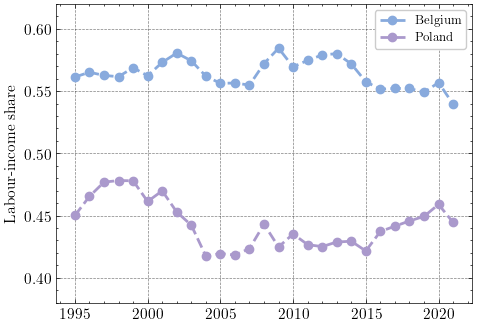

geo_code
Belgium    0.564
Poland     0.443
dtype: float64


In [28]:
# labour share of GDP
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(
    labour_income_shares.index, labour_income_shares["Belgium"], color="#88AADD", label="Belgium",
    lw=2.0, marker="o", ls="--"
)

ax.plot(
    labour_income_shares.index, labour_income_shares["Poland"], color="#AA99CC", label="Poland",
    lw=2.0, marker="o", ls="--"
)

ax.set_ylabel("Labour-income share")
ax.set_ylim((0.38,0.62))

ax.legend()

plt.tight_layout()
plt.savefig("output/labour_income.png")
plt.show()

print(labour_income_shares.mean().round(3))

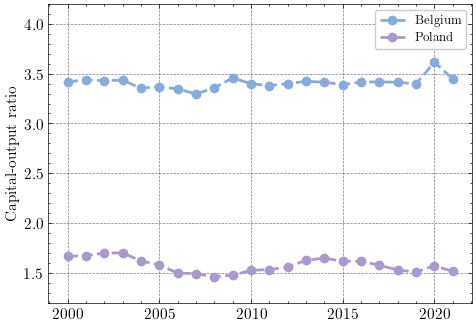

geo_code
Belgium    3.410
Poland     1.576
dtype: float64


In [27]:
# capital output plot
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(
    capital_output.index, capital_output["Belgium"],
    color="#88AADD", label="Belgium",
    lw=2.0, marker="o", ls="--"
)

ax.plot(
    capital_output.index, capital_output["Poland"],
    color="#AA99CC", label="Poland",
    lw=2.0, marker="o", ls="--"
)

ax.set_ylabel("Capital-output ratio")
ax.set_ylim((1.2,4.2))

ax.legend(title="", loc="upper right")

plt.tight_layout()
plt.savefig("output/cap_output.png")
plt.show()

print(capital_output.mean().round(3))